# Fetching data from Kaggle for Titanic Prediction


In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 100)
df = pd.read_csv(r"C:\Users\Aksha\Desktop\Data Science Fundamentals\titanic\train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


|Variable|	Definition|	Key|
|---|---|---|
|survival|	Survival|	0 = No, 1 = Yes|
|pclass|	Passenger Class|	1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|	Sex|	
|Age	|Age in years|	
|sibsp	|# of siblings / spouses aboard the Titanic|	
|parch	|# of parents / children aboard the Titanic|	
|ticket	|Ticket number|	
|fare	|Passenger fare|	
|cabin	|Cabin number|	
|embarked	|Port of Embarkation|	C = Cherbourg, Q = Queenstown, S = Southampton|
<br>

Variable Notes
pclass: A proxy for socio-economic status (SES)
- 1st = Upper
- 2nd = Middle
- 3rd = Lower

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

sibsp: The dataset defines family relations in this way...
- Sibling = brother, sister, stepbrother, stepsister
- Spouse = husband, wife (mistresses and fiancés were ignored)

parch: The dataset defines family relations in this way...
- Parent = mother, father
- Child = daughter, son, stepdaughter, stepson
- Some children travelled only with a nanny, therefore parch=0 for them.



> -----
> **Observataions**:
> - Survival is the number of passengers who survived. Survival is 1 if the passenger survived, 0 if he/she did not.
> - needs to be encoded: pclass, sex, embarked
> - PassengerID, ticket, name are unique identifiers for each passenger and hence must not be used as features.
> - Need to understand what "Age is fractional if less than 1" means.
> - PassengerId is important as it needs to be used in the final submission file. 
> ---

# Exploratory Data Analysis

In [5]:
for i in df.columns:
    print(df[i].value_counts(dropna=False))
    print("------------------")

PassengerId
891    1
1      1
2      1
3      1
4      1
      ..
31     1
32     1
33     1
34     1
35     1
Name: count, Length: 891, dtype: int64
------------------
Survived
0    549
1    342
Name: count, dtype: int64
------------------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
------------------
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Uruchurtu, Don. Manuel E                               1
Spencer, Mrs. William Augustus (Marie Eugenie)         1
Glynn, Miss. Mary Agatha                               1
Wheadon, Mr. Edward H                                  1
Meyer, Mr. Edgar Joseph                                1
Name: count, Length: 891, dtype: int64
---------

**Obeservation** : 
- PassengerId is the unique identifier for each passenger. Should be dropped from the dataset for training purposes.
- **Survived** is what we need to predict. I seems to have no null values. 
- **Passenger** class looks good to go. It is already encoded and seems to have no null vaulues.
- **Name** is clearly unique. I can drop it from the dataset.
- **Sex** has either male or female. with no null values. need to encode it.
- **Age** is a numeric value. it has 177 null values. need to handle it.
- **SibSp** is a numeric value. with no null values. need to check how feasible it is to predict the survival of a passenger.
- **Parch** is a numeric value. with no null values. need to check how feasible it is to predict the survival of a passenger.
- **Ticket** is also mostly unique. I can drop it from the dataset.
- **fare** might be a good indicator, maybe it can be bucketed into different ranges.
- **cabin** is mostly null with 687 null values. can be dropped from the dataset.
- **embarked** is a little odd. need to encode it. and it has two null values. it can probably be replaced woth 'S' which has the higest number of embarked. 

In [6]:
# Data Cleaning
# Dropping unnecessary columns or columns with large number of NaN values
df_cleaned = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).copy()
 
 
print("number of rows in the data set is ", df_cleaned.shape[0])
print("number of columns in the data set is ", df_cleaned.shape[1])

df_cleaned.dtypes

number of rows in the data set is  891
number of columns in the data set is  8


Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

 They are all the correct data types so i dont need to change them.

In [7]:
# Percentage of missing values in each column
df_cleaned.isnull().sum()/df_cleaned.shape[0] *100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

- Embarked doesnt have too many missing values so i can just replace it with the mode of the column. 
- Age on the other hand has 20% of the data missing. SInce age is important and 20% of the data missing isnt that bad i can just replace it with the an aggregation of the column.(TBD)

outliers for Survived: 0
outliers for Pclass: 0
outliers for Age: 8
outliers for SibSp: 35
outliers for Parch: 15
outliers for Fare: 95


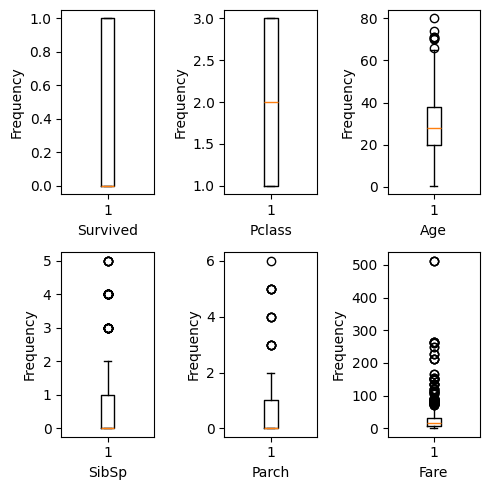

                    Fare
count         712.000000
missing         0.000000
mean           34.567251
std            52.938648
min             0.000000
25%             8.050000
50% (median)   15.645850
75%            33.000000
max           512.329200
skew            4.667009
kurtosis       31.013377


In [8]:
num_cols = df_cleaned.select_dtypes(exclude=['object']).columns

fig,axes = plt.subplots(figsize=(5,5), ncols=3, nrows=2)
axes = axes.flatten()
temp_df = df_cleaned.dropna()
for idx, columns in enumerate(num_cols):
    ax = axes[idx]
    values = temp_df[columns]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(f"outliers for {columns}:", len(values[(values < lower) | (values > upper)]))
    ax.boxplot(values, whis=1.5)
    ax.set_xlabel(columns)
    ax.set_ylabel('Frequency')
    ax.set_label(columns)
plt.tight_layout()
plt.show()



def detailed_summary(series):
    return pd.Series({
        'count': series.count(),
        'missing': series.isnull().sum(),
        'mean': series.mean(),
        'std': series.std(),
        'min': series.min(),
        '25%': series.quantile(0.25),
        '50% (median)': series.median(),
        '75%': series.quantile(0.75),
        'max': series.max(),
        'skew': series.skew(),
        'kurtosis': series.kurt()
    })

print(temp_df[['Fare']].apply(detailed_summary))
del temp_df

From what it looks like we can replace the null values with the mean of the column for age, and the most common value for embarked.

In [9]:
# replacing all the null vaues in the Age and Embarked columns
df_cleaned.fillna({'Age': round(df_cleaned['Age'].mean(),0), 'Embarked': df_cleaned['Embarked'].mode()[0]}, inplace=True)

print(df_cleaned.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [10]:
df_cleaned

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,30.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [11]:
def encode_cols(df, cat_cols):
    df = df.copy() 
    for col in cat_cols:
        if df[col].nunique() > 2:
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
        else:
            df[col] = df[col].astype('category').cat.codes
    return df

cat_cols = df_cleaned.select_dtypes(include=['object']).columns
df_encoded = encode_cols(df_cleaned, cat_cols)
df_encoded['Embarked_Q']=df_encoded.Embarked_Q.astype('int')
df_encoded['Embarked_S']=df_encoded.Embarked_S.astype('int')
df_encoded.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


<Axes: >

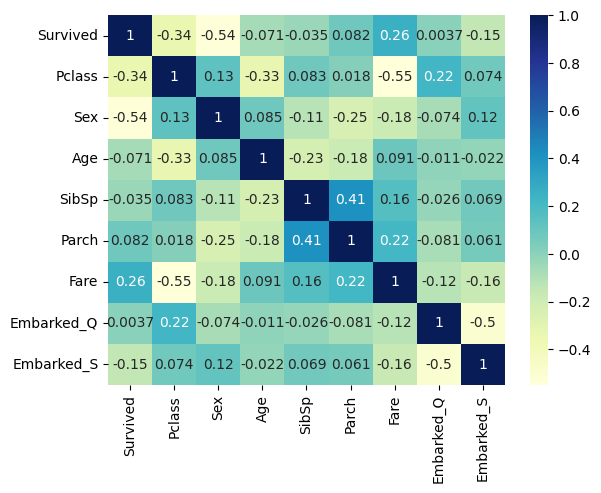

In [12]:
# correlation analysis 

sns.heatmap(df_encoded.corr(), annot=True, cmap='YlGnBu')

- Sex has a strong negative correlation (-0.54) with survival.
- Fare has a moderate positive correlation (0.26) with survival, indicating higher-paying passengers had better survival chances.
- Pclass shows a negative correlation (-0.34) with survival, meaning passengers in higher classes were more likely to survive.
- SibSp and Parch have a positive correlation (0.41) with each other.

# Simple Perceptron

To start off i will only be using the age and sex of the passengers and the survival of the passengers.

In [13]:
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split

df_encoded_filtered = df_encoded[['Age', 'Sex', 'Survived']].copy()
X = df_encoded_filtered.drop(columns=['Survived']).values
y = df_encoded_filtered['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
df_encoded_filtered

,Age,Sex,Survived
0,22.0,1,0
1,38.0,0,1
2,26.0,0,1
3,35.0,0,1
4,35.0,1,0
...,...,...,...
886,27.0,1,0
887,19.0,0,1
888,30.0,0,0
889,26.0,1,1


### Components of a Perceptron

A simple perceptron consists of:

- **Input Features**: $x_1, x_2, \dots, x_n$
- **Weights**: $w_1, w_2, \dots, w_n$
- **Bias** term: $b$
- **Activation Function** — typically a step function for binary output (0 or 1)

---

### Net Input Calculation

The perceptron computes a **weighted sum** of its inputs and adds a bias:

$$
z = \sum_{j=1}^{n} w_j x_j + b = \mathbf{w} \cdot \mathbf{x} + b
$$

Where:
- $\mathbf{w}$ is the weight vector  
- $\mathbf{x}$ is the input vector

---

### Activation Function (Decision Function)

The output $\hat{y}$ is computed using a **step function**:

$$
\hat{y} = 
\begin{cases}
1 & \text{if } z > \theta \\
0 & \text{otherwise}
\end{cases}
$$

Or more concisely:

$$
\hat{y} = \text{step}(z)
$$

---

### Perceptron Learning Algorithm (Training Steps)

The goal is to learn the weights $\mathbf{w}$ and bias $b$ so that the perceptron correctly classifies the training data.

#### Steps:

1. **Initialize** the weights and bias unit to 0 or small random numbers.

2. **For each training example** $x^{(i)}$:

   a. **Compute the output value** $\hat{y}^{(i)}$

   b. **Update** the weights and bias unit:

   $$
   w_j := w_j + \eta \left( y^{(i)} - \hat{y}^{(i)} \right) x_j^{(i)}
   $$

   $$
   b := b + \eta \left( y^{(i)} - \hat{y}^{(i)} \right)
   $$

   Where:
   - $\eta$ is the learning rate (a small constant like 0.01)  
   - $y^{(i)}$ is the true label  
   - $\hat{y}^{(i)}$ is the predicted output

Repeat the process for all training examples for several epochs until convergence or until the weights stop changing significantly.

---



In [14]:
class Perceptron:
    def __init__(self, eta = 0.01 , n_iter =50):
        self.model = 'Perceptron'
        self.random_state = 1
        self.eta = eta
        self.n_iter = n_iter
    
    def net_input(self,X):
        return np.dot(X,self.w_) + self.b_
    
    def predict(self,X):
        return np.where(self.net_input(X) >= 0.0,1,0)
    
    def fit(self,X,y):
        rgen = np.random.RandomState(self.random_state)
        self.w_= rgen.normal(loc=0.0,scale=0.01,size=X.shape[1]) # loc is the mean, scale is the standard deviation, size is the shape of the array
        self.b_ = np.float64(0.)
        
        self.errors_=[]
        
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self
       
       


0.6815642458100558


(0.0, 403.2)

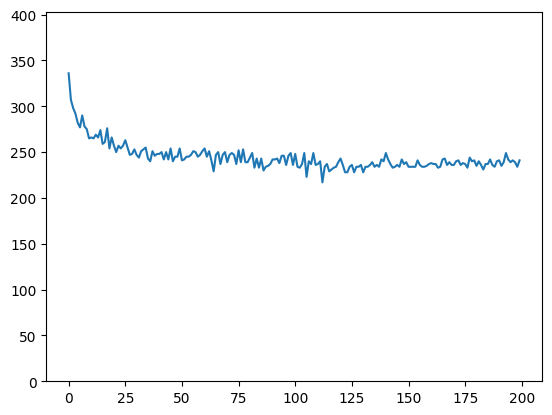

In [15]:
# Training the Perceptron model     
simple_perceptron = Perceptron(eta=0.01, n_iter=200)
simple_perceptron.fit(X_train,y_train)
simple_perceptron.predict(X_test)
from sklearn.metrics import accuracy_score
y_pred = simple_perceptron.predict(X_test)
print(accuracy_score(y_test,y_pred))

plt.plot(simple_perceptron.errors_)
plt.ylim([0,max(simple_perceptron.errors_)*1.2])

In [16]:
# Using more features to train the model 

X = df_encoded.drop(columns=['Survived']).values
y = df_encoded['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
df_encoded

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0,1
887,1,1,0,19.0,0,0,30.0000,0,1
888,0,3,0,30.0,1,2,23.4500,0,1
889,1,1,1,26.0,0,0,30.0000,0,0


In [17]:
etas = [0.001, 0.01, 0.1, 0.5]
best_eta = 0
best_accuracy = 0
for _eta in etas:
    simple_perceptron = Perceptron(eta=_eta, n_iter=200)
    simple_perceptron.fit(X_train,y_train)
    simple_perceptron.predict(X_test)
    y_pred = simple_perceptron.predict(X_test)
    score = accuracy_score(y_test,y_pred)
    if score > best_accuracy:
        best_eta = _eta
        best_accuracy = score
        print(f"Best eta so far: {_eta} with accuracy: {score}")
print("-----------------------")
print(f"Best eta found: {best_eta} with accuracy: {best_accuracy}")  


Best eta so far: 0.001 with accuracy: 0.7374301675977654
Best eta so far: 0.01 with accuracy: 0.7541899441340782
-----------------------
Best eta found: 0.01 with accuracy: 0.7541899441340782


0.7541899441340782


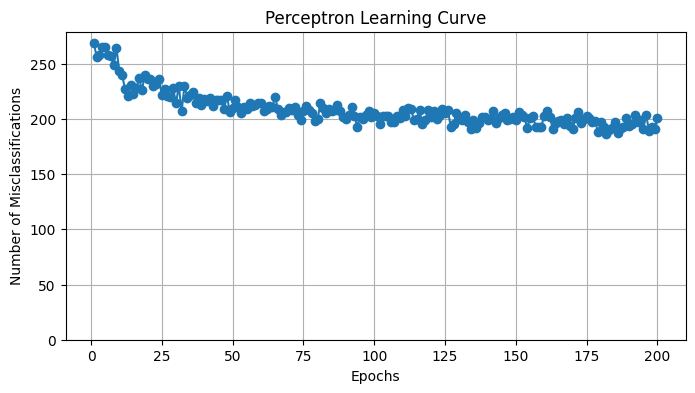

In [18]:
# Training the Perceptron model     
simple_perceptron = Perceptron(eta=0.01, n_iter=200)
simple_perceptron.fit(X_train,y_train)
simple_perceptron.predict(X_test)

y_pred = simple_perceptron.predict(X_test)
print(accuracy_score(y_test,y_pred))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(simple_perceptron.errors_) + 1), simple_perceptron.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of Misclassifications')
plt.title('Perceptron Learning Curve')
plt.grid(True)
plt.ylim(0, max(simple_perceptron.errors_)+10)
plt.show()

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[82 28]
 [16 53]]
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       110
           1       0.65      0.77      0.71        69

    accuracy                           0.75       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.77      0.75      0.76       179



# Writing Logistic Regression in Python and comparing it with scikit-learn

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression    
from sklearn.pipeline import Pipeline


def train_and_predict(X_train, X_test, y_train, y_test, model):
    """Train and predict the model on the given data."""
    preprocessor = ColumnTransformer(
        transformers=[
            ('sex_encoder', OneHotEncoder(drop='if_binary'), ['Sex']),           
            ('embarked_encoder', OneHotEncoder(drop='first'), ['Embarked']),    
            ('scaler', StandardScaler(), ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'])
        ],
        remainder='passthrough'  
    )
    pipeline_steps = [('encoding',preprocessor),
                        ('clf', model)]
    pipeline = Pipeline(pipeline_steps)
    pipeline.fit(X_train, y_train)
    train_pred = pipeline.predict(X_train)
    print("testing_accuracy:",accuracy_score(y_train, train_pred))

    test_pred = pipeline.predict(X_test)
    print("testing_accuracy:",accuracy_score(y_test, test_pred))
    
    
    return test_pred

class self_LogisticRegression:

    """Logistic regression classifier."""
    def __init__(self, eta=0.01, n_iter=50, random_state=1, l2 = 0.0):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.l2 = l2
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_
    def sigmoid(self, x):
        """Calculate sigmoid of x"""
        return 1.0 / (1.0 + np.exp(-x))
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.sigmoid(self.net_input(X)) >= 0.5, 1, 0)
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = 0.
        self.losses_ = []
        
        m = X.shape[0]  # Number of samples
        
        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.sigmoid(net_input)
            errors = (y - output)
            
            # Gradient update with L2 penalty (excluding bias)
            self.w_ += self.eta * ((X.T.dot(errors) / m) - (self.l2 / m) * self.w_)
            self.b_ += self.eta * errors.mean()
            
            # Loss function with L2 regularization term
            loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / m
            loss += (self.l2 / (2 * m)) * np.sum(self.w_ ** 2)
            self.losses_.append(loss)
        
        return self

In [21]:
X = df_cleaned[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df_cleaned['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

lr = LogisticRegression()
predictions = train_and_predict(X_train, X_test, y_train, y_test, model=lr)


testing_accuracy: 0.8033707865168539
testing_accuracy: 0.7988826815642458


In [22]:
    
self_lr = self_LogisticRegression(eta=0.01, n_iter=50, random_state=1, l2 = 0.1)

predictions = train_and_predict(X_train, X_test, y_train, y_test, model=self_lr)

testing_accuracy: 0.702247191011236
testing_accuracy: 0.7374301675977654


# Using Pytorch

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch 
import torch.nn as nn 
from torch.utils.data import TensorDataset, DataLoader



X = df_cleaned[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df_cleaned['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

preprocessor = ColumnTransformer(
        transformers=[
            ('binary_encoding', OneHotEncoder(drop='if_binary'), ['Sex']),           
            ('onehot_encoding', OneHotEncoder(drop='first'), ['Embarked']),    
            ('scaler', StandardScaler(), ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'])
        ],
        remainder='passthrough'  
    )


X_train_std = preprocessor.fit_transform(X_train)
X_test_std = preprocessor.transform(X_test)

X_train_std = torch.from_numpy(X_train_std).float()
X_test_std = torch.from_numpy(X_test_std).float()

y_train = torch.from_numpy(y_train.values).long()
y_test = torch.from_numpy(y_test.values).long()

print(X_train_std.shape)
print(y_train.shape)
print(X_test_std.shape)
print(y_test.shape)


train_ds = TensorDataset(X_train_std, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

torch.Size([712, 8])
torch.Size([712])
torch.Size([179, 8])
torch.Size([179])


Epoch 10/100 | Train Loss: 0.4190 Acc: 0.8258 | Val Loss: 0.4015 Acc: 0.8045
Epoch 20/100 | Train Loss: 0.4044 Acc: 0.8385 | Val Loss: 0.3975 Acc: 0.8380
Epoch 30/100 | Train Loss: 0.3961 Acc: 0.8427 | Val Loss: 0.3952 Acc: 0.8212
Epoch 40/100 | Train Loss: 0.3890 Acc: 0.8413 | Val Loss: 0.4118 Acc: 0.7989
Epoch 50/100 | Train Loss: 0.3827 Acc: 0.8441 | Val Loss: 0.4017 Acc: 0.8268
Epoch 60/100 | Train Loss: 0.3823 Acc: 0.8511 | Val Loss: 0.4086 Acc: 0.8156
Epoch 70/100 | Train Loss: 0.3796 Acc: 0.8497 | Val Loss: 0.4027 Acc: 0.8212
Epoch 80/100 | Train Loss: 0.3765 Acc: 0.8511 | Val Loss: 0.4125 Acc: 0.8045
Epoch 90/100 | Train Loss: 0.3723 Acc: 0.8427 | Val Loss: 0.4008 Acc: 0.8045
Epoch 100/100 | Train Loss: 0.3722 Acc: 0.8413 | Val Loss: 0.4151 Acc: 0.8101


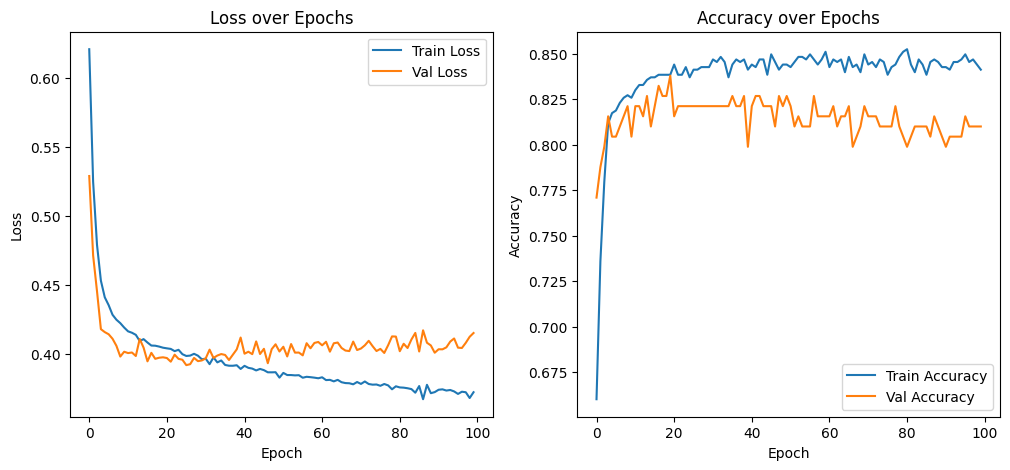

In [69]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        return x 
    
input_size = X_train_std.shape[1]
hidden_size = 16
output_size = 2 
model = Model(input_size, hidden_size, output_size)

learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 100
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss, running_correct = 0.0, 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)
        running_correct += (torch.argmax(pred, dim=1) == y_batch).sum().item()

    train_loss = running_loss / len(train_dl.dataset)
    train_acc = running_correct / len(train_dl.dataset)
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_std)
        val_loss = loss_fn(val_pred, y_test).item()
        val_correct = (torch.argmax(val_pred, dim=1) == y_test).sum().item()

    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_correct / len(y_test))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_correct / len(y_test):.4f}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Train Accuracy')
plt.plot(val_acc_hist, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

In [66]:
df_submisson = pd.read_csv(r"C:\Users\Aksha\Desktop\Data Science Fundamentals\titanic\test.csv")
df_submisson

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [72]:
# 1. Fill nulls in submission set
df_submission_filled = df_submisson.copy()
df_submission_filled['Age'] = df_submission_filled['Age'].fillna(df_cleaned['Age'].median())
df_submission_filled['Fare'] = df_submission_filled['Fare'].fillna(df_cleaned['Fare'].median())
df_submission_filled['Embarked'] = df_submission_filled['Embarked'].fillna(df_cleaned['Embarked'].mode()[0])

# 2. Extract input features
X_submission = df_submission_filled[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# 3. Preprocess
X_submission_std = preprocessor.transform(X_submission)
X_submission_std = torch.from_numpy(X_submission_std).float()

# 4. Predict
model.eval()
with torch.no_grad():
    logits = model(X_submission_std)
    predictions = torch.argmax(logits, dim=1).numpy()

# 5. Save CSV
submission_df = pd.DataFrame({
    'PassengerId': df_submisson['PassengerId'],
    'Survived': predictions
})
submission_df.to_csv(r"C:\Users\Aksha\Desktop\Data Science Fundamentals\titanic\submission.csv", index=False)